In [1]:
pip install scanpy anndata

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [51]:
import pandas as pd
from scipy.io import mmread
import scipy.sparse
import scanpy as sc

In [52]:
X = mmread("GSE161824_A549_TP53.processed.matrix.mtx").tocsr()

In [61]:
# Load gene names and barcodes
genes = pd.read_csv("GSE161824_A549_TP53.processed.genes.csv", header=None)
barcodes = pd.read_csv("GSE161824_A549_TP53.processed.cells.csv", header=None)

In [62]:
import anndata as ad
adata = ad.AnnData(X)
adata.var_names = genes[0].values  # column 1 = gene symbols
adata.obs_names = barcodes[0].values

In [63]:
print(adata)

AnnData object with n_obs × n_vars = 85778 × 1224


In [64]:
barcodes

,0
0,ACGCCGATCAGGATCT-1-0
1,ACGGAGATCCAGAAGG-1-0
2,AGACGTTGTGTGCGTC-1-0
3,CAGCATAGTATCAGTC-1-0
4,CGCCAAGTCATATCGG-1-0
...,...
85773,TACACGAAGGCACATG-1-31
85774,TAGGCATTCCACGAAT-1-31
85775,TGAGAGGCATGGTCTA-1-31
85776,TGGCGCATCAGTACGT-1-31


In [65]:
v2c = pd.read_csv('/work/users/k/r/kritis/single_cell/crispr_cell_mapping/PRJNA679579_mapping.csv')

In [66]:
v2c = v2c[v2c['gene']=='TP53']

In [89]:
barcodes_mut = pd.read_csv('/work/users/k/r/kritis/database_analysis/TP53_example/ARHGAP35_barcodes.csv')

In [90]:
barcode_list = barcodes_mut['cell_barcode'].tolist()

In [91]:
adata.obs['mut'] = adata.obs_names.isin(barcode_list)
# Optional: make it clearer
adata.obs['mut'] = adata.obs['mut'].map({True: 'Target', False: 'Other'})

In [92]:
adata_target = adata[adata.obs['mut'] == 'Target'].copy()
adata_other = adata[adata.obs['mut'] == 'Other'].copy()

In [93]:
genes = pd.read_csv('/work/users/k/r/kritis/single_cell/PRJNA679579/ARHGAP3_example/genelist.csv')

In [94]:
gene_list = genes['0'].tolist()

In [95]:
gene_list = [g for g in gene_list if g in adata.var_names]
print(f"Using {len(gene_list)} genes from your list.")

Using 4 genes from your list.


In [96]:
gene_list

['SLC12A2', 'PRDX1', 'PKIB', 'CHAF1A']

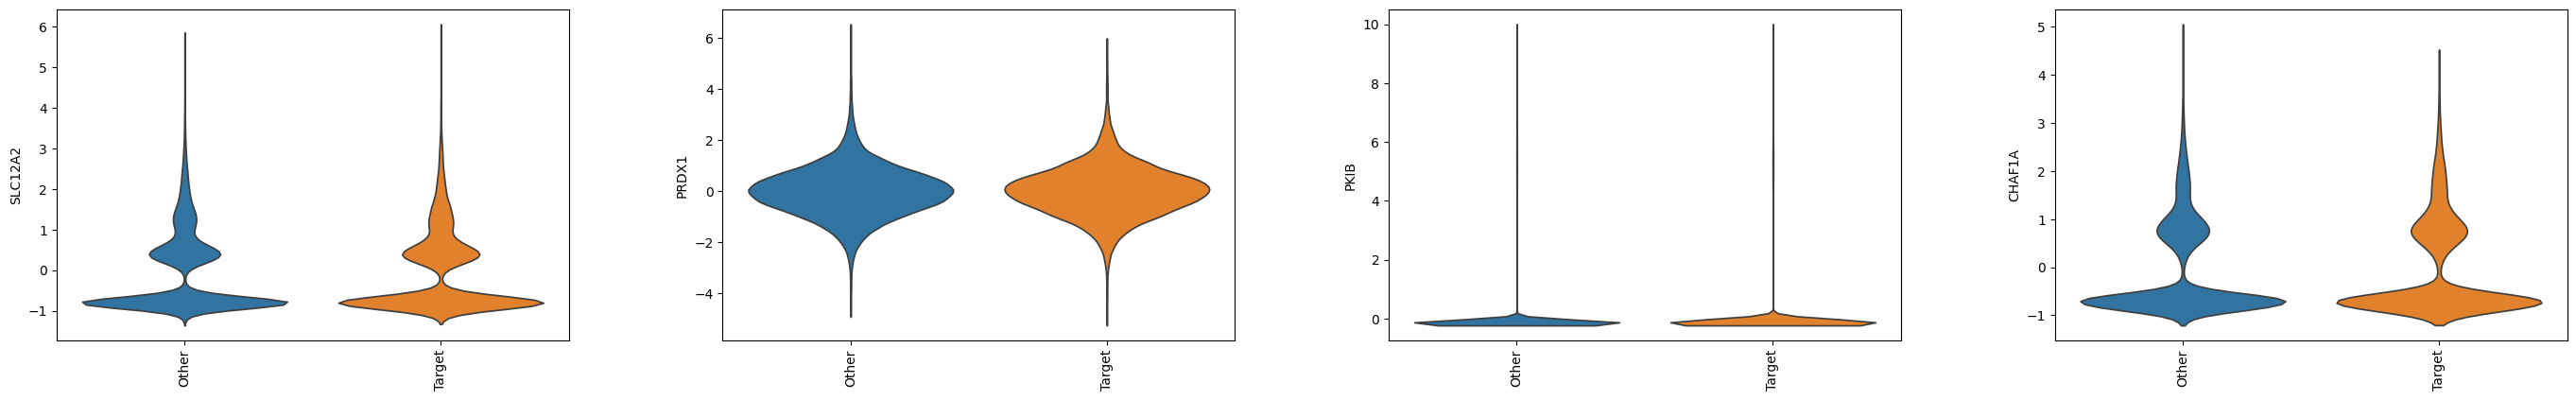

In [97]:
sc.pl.violin(adata, keys=gene_list, groupby='mut', stripplot=False, jitter=False, rotation=90)

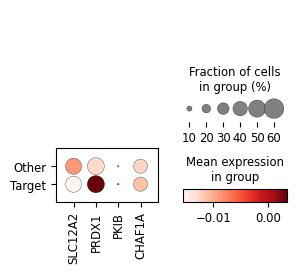

In [98]:
sc.pl.dotplot(adata, var_names=gene_list, groupby='mut')

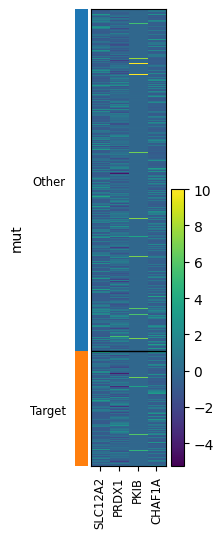

In [99]:
sc.pl.heatmap(adata, var_names=gene_list, groupby='mut', use_raw=False)

In [101]:
import numpy as np

# Convert sparse to dense if needed
X = adata[:, gene_list].X.toarray() if not isinstance(adata.X, np.ndarray) else adata[:, gene_list].X

# Create a DataFrame of expression values
import pandas as pd
expr_df = pd.DataFrame(X, columns=gene_list, index=adata.obs_names)
expr_df['mut'] = adata.obs['mut'].values

# Group by 'Target' and 'Other' and compute mean expression
signature_stats = expr_df.groupby('mut').mean()
print(signature_stats)

         SLC12A2     PRDX1      PKIB    CHAF1A
mut                                           
Other  -0.008717 -0.012768 -0.008685 -0.012526
Target -0.015552  0.003317 -0.004709 -0.011211


/tmp/ipykernel_3398911/1533957719.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  signature_stats = expr_df.groupby('mut').mean()


In [102]:
gene_set = [g for g in gene_list if g in adata_target.var_names]

# All other genes
other_genes = [g for g in adata_target.var_names if g not in gene_set]

In [103]:
gene_idx = [adata_target.var_names.get_loc(g) for g in gene_set]
other_idx = [i for i in range(adata_target.shape[1]) if i not in gene_idx]

In [104]:
X = adata_target.X.toarray() if not isinstance(adata_target.X, np.ndarray) else adata_target.X

# Compute per-cell mean expression
sig_expr = X[:, gene_idx].mean(axis=1)
other_expr = X[:, other_idx].mean(axis=1)

/tmp/ipykernel_3398911/1962594932.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Gene Set', y='Average Expression', data=df_long, inner='box', palette='pastel')


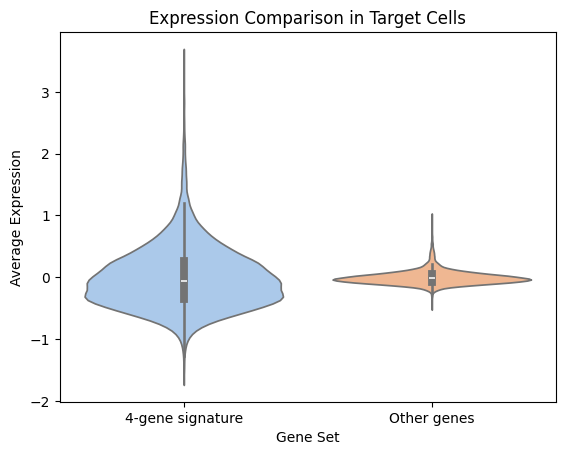

In [105]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Tidy DataFrame
df_long = pd.DataFrame({
    '4-gene signature': sig_expr,
    'Other genes': other_expr
}).melt(var_name='Gene Set', value_name='Average Expression')

# Plot
sns.violinplot(x='Gene Set', y='Average Expression', data=df_long, inner='box', palette='pastel')
plt.title("Expression Comparison in Target Cells")
plt.show()

In [106]:
from scipy.stats import wilcoxon

stat, pval = wilcoxon(sig_expr, other_expr)
print(f"Wilcoxon signed-rank test p-value: {pval:.3e}")

Wilcoxon signed-rank test p-value: 3.052e-30
